# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Dieuwke Meindertsma
* Username: dmeindertsma
* Student number: s6446493
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

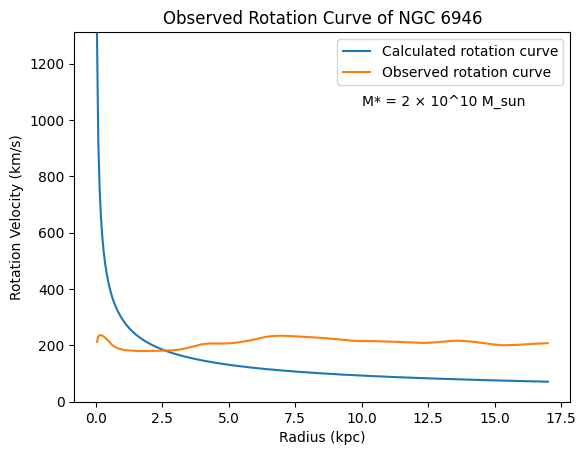

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Reading the file:

radius, rotation_velocity = np.loadtxt('rotcur.dat', comments="#", unpack=True)

# so the calculation of v does not have to divide by 0

mask = radius > 0
radius = radius[mask]
rotation_velocity = rotation_velocity[mask]

G = 4.3e-6               # in units km^2*kpc*M_sun^-1*s^-2
M = 2e10                 # in units M_sun

v_rot = np.sqrt(G * M / radius)          # To calculate v

kepler_data = np.vstack((radius, v_rot)).T  # To save the  multiple arrays but transposed for columns

np.savetxt('keplerian_curve.txt', kepler_data,  header="radius(kpc) velocity(km/s)")

r_kep, v_kep = np.loadtxt('keplerian_curve.txt', comments="#", unpack=True)

plt.plot(r_kep, v_kep, label="Calculated rotation curve")
plt.plot(radius, rotation_velocity, label="Observed rotation curve")

plt.xlabel("Radius (kpc)")
plt.ylabel("Rotation Velocity (km/s)")
plt.title("Observed Rotation Curve of NGC 6946")
plt.legend()
plt.ylim(0, np.max(v_kep)) # Forcing y limits

plt.annotate("M* = 2 × 10^10 M_sun", xy=(10, 1050)) # Annotation of relevant data

plt.show()

# Observation: the observed data stays approximately constant at larger radii and the kepler curve decreases. 
# This implies unseen mass, and therefore, dark matter.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

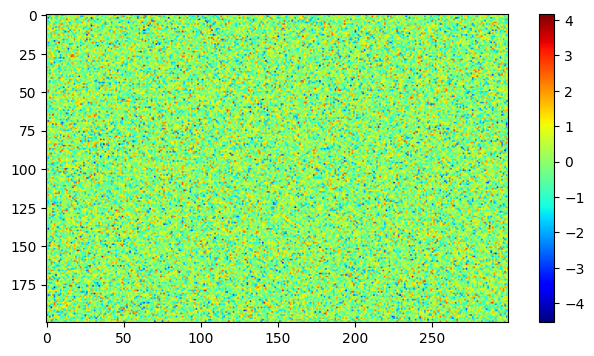

The standard deviation = 0.9938447134116646 and the mean is = -0.032553259361674476


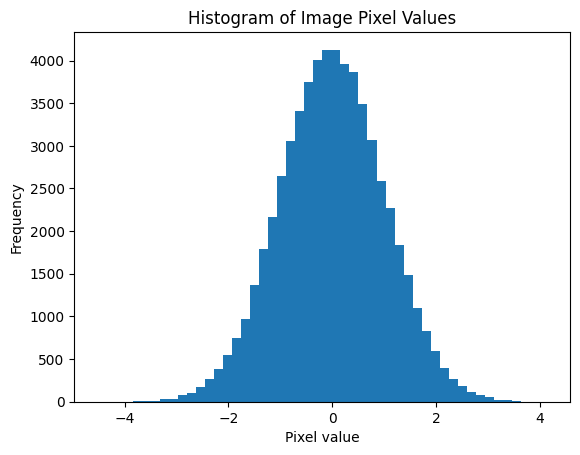

In [4]:
import numpy as np
import matplotlib.pyplot as plt

image = np.random.normal(loc=0, scale=1.0, size=(200, 300))
plt.figure(figsize=(8,4))
plt.imshow(image, cmap='jet')
plt.colorbar()
plt.show()

slice30=image[50:80,30:60]
slice_mean = np.mean(slice30)
slice_std = np.std(slice30)
print(f"The standard deviation = {slice_std} and the mean is = {slice_mean}")
# As expected they are close to 1.0 and 0.

image2 = image.flatten() # To flatten the image

plt.figure()
plt.hist(image2 , bins=50)
plt.title("Histogram of Image Pixel Values")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

# This looks like a Gaussian normal distribution

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Ellipse with center: (0, 0), semi major axis: 3, semi minor axis: 2 and angle: 0
Area: 18.84955592153876
Perimeter: 15.865439589251233


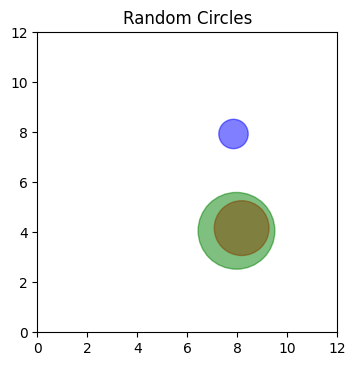

In [6]:
from matplotlib.patches import Ellipse
import numpy as np
from matplotlib.patches import Ellipse, Circle

# Copied code:
class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        # Adding variables
        self.a = semi_major
        self.b = semi_minor
        self.xc = xc
        self.yc = yc
        self.angle = position_angle
        
    # Method for area
    def area(self):
        """Return the area of the ellipse"""
        return np.pi*self.a*self.b
    
    # Method for perimeter
    def perimeter(self):
        """Return the perimeter of the ellipse"""
        h = ((self.a - self.b)**2) / ((self.a + self.b)**2)
        return np.pi * (self.a + self.b) * (1 + 3*h/(10 + np.sqrt(4 - 3*h)))
    
    # String
    def __str__(self):
        s = f"Ellipse with center: ({self.xc}, {self.yc}), semi major axis: {self.a}, semi minor axis: {self.b} and angle: {self.angle}"
        return s
    
# Example ellipse

ellipse = AstroEllipse(0, 0, 3, 2, 0)
print(ellipse)
print("Area:", ellipse.area())
print("Perimeter:", ellipse.perimeter())
    
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, 0, **args)  # Circle: a=b=radius, angle=0
        self.radius = radius
        
fig = plt.figure(figsize=(3,3))
frame = fig.add_axes([0,0,1,1])  # axes fill figure

colors = ['red', 'green', 'blue']

for color in colors:
    xc, yc = np.random.uniform(2, 10, 2)         # to keep the centre in the figure
    radius = np.random.uniform(0.5, 2)           # radius from 0.5 to 2
    circle = MyCircle(xc, yc, radius, edgecolor=color, facecolor=color, alpha=0.5)
    frame.add_patch(circle)                      # adding the circle to the figure

frame.set_xlim(0, 12)
frame.set_ylim(0, 12)
frame.set_aspect('equal')       # Making the axes equal
plt.title("Random Circles")
plt.show()


In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

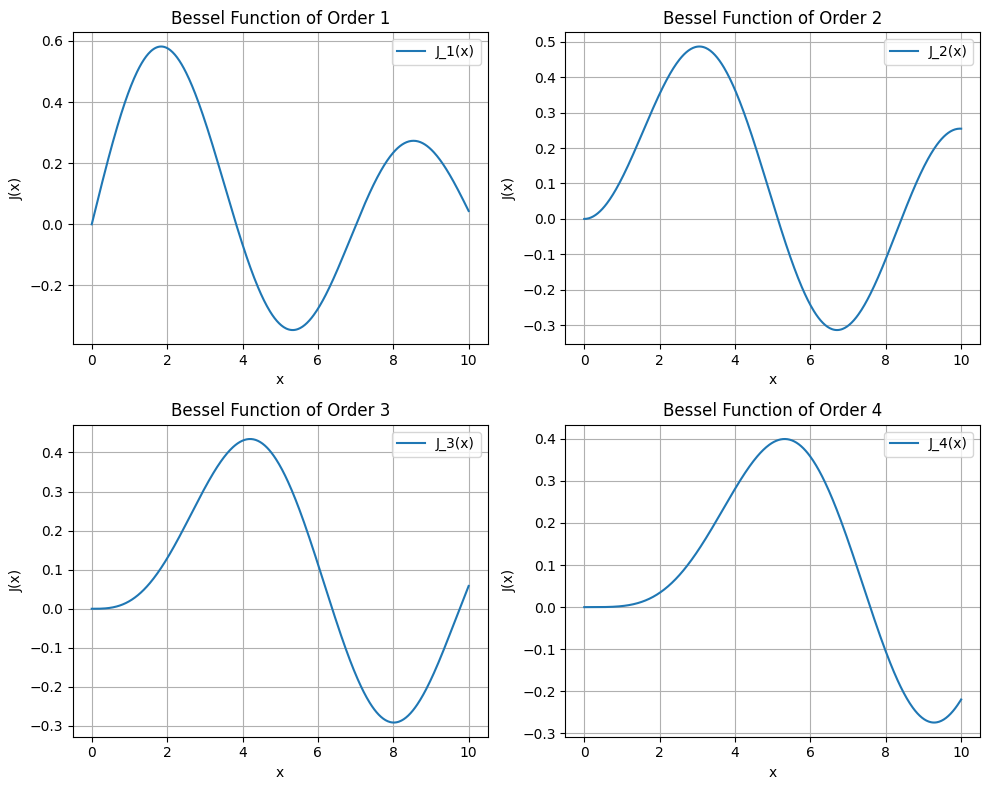

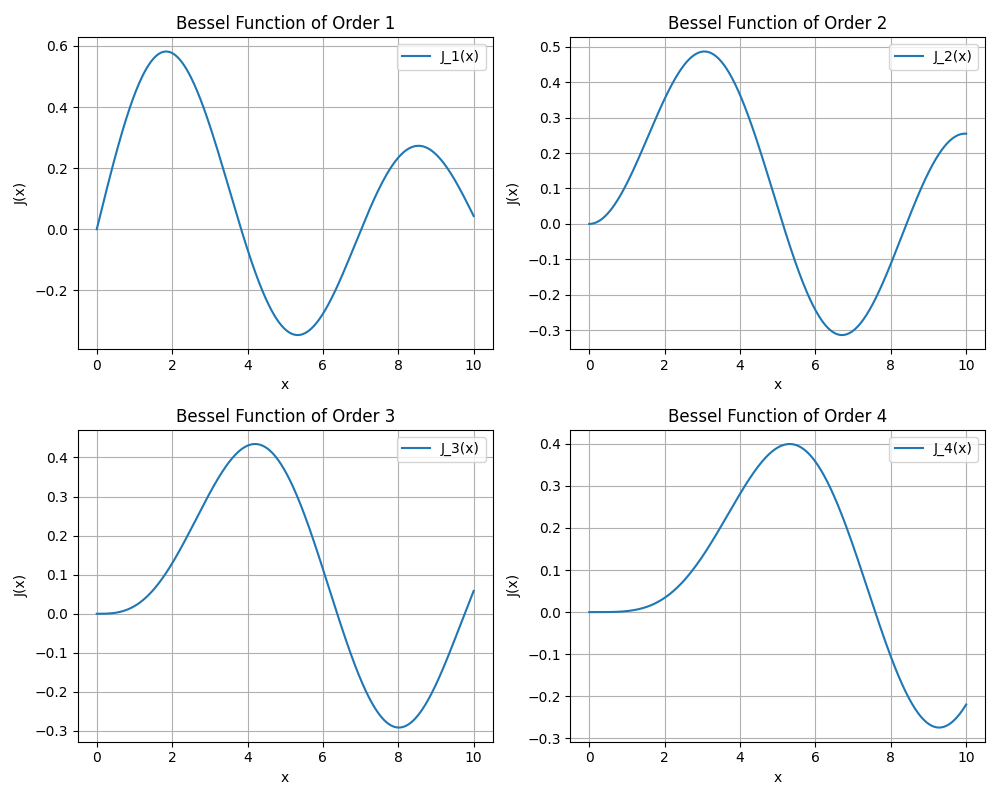

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from IPython.display import Image  # to display PNG in notebook

# Define x values from 0 to 10
x = np.linspace(0, 10, 500)

# Define Bessel function orders
orders = [1, 2, 3, 4]

# Create 2x2 subplots (mosaic)
fig = plt.figure(figsize = (10,8))
for i, a in enumerate(orders):  
    frame = fig.add_subplot(2, 2, i + 1) 
    frame.plot(x, jv(a, x), label=f'J_{a}(x)')
    frame.set_title(f'Bessel Function of Order {a}')
    frame.set_xlabel('x')
    frame.set_ylabel('J(x)')
    frame.legend()
    frame.grid(True)

# Adjust layout
plt.tight_layout()

# Saving as png
plt.savefig('bessel.png', transparent=True)

plt.show()

Image(filename='bessel.png')

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

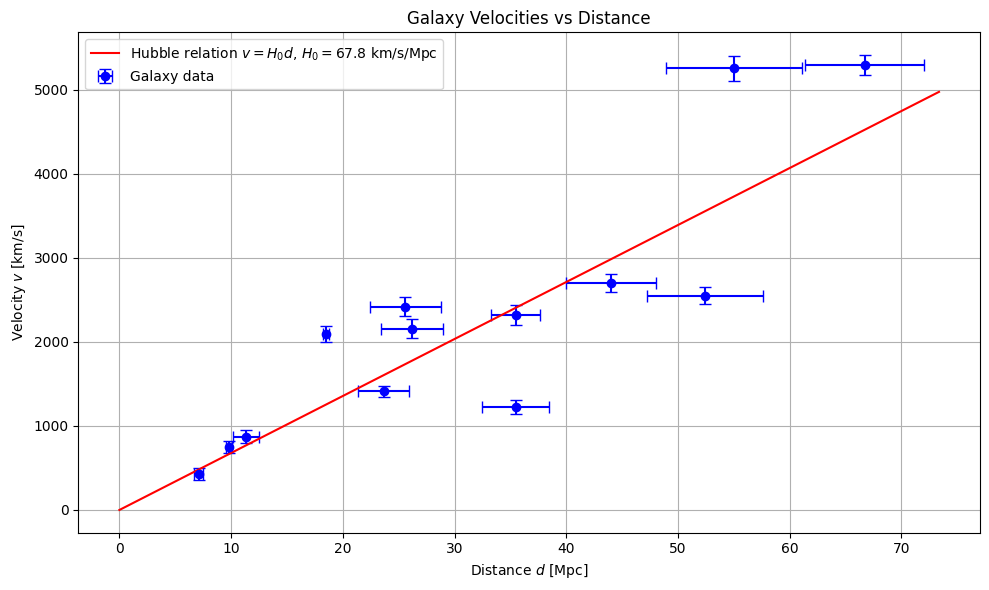

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

arr = np.array(data).reshape(-1,4)

# Slicing to unpack
d = arr[:, 0]        # distance (Mpc)
v = arr[:, 1]        # velocity (km/s)
err_d = arr[:, 2]    # error in distance
err_v = arr[:, 3]    # error in velocity

# Hubble constant
H0 = 67.8  # km/s/Mpc

# Create figure
fig = plt.figure(figsize=(10, 6))
frame = fig.add_subplot(1, 1, 1)

# Plot data with error bars
frame.errorbar(d, v, xerr=err_d, yerr=err_v, fmt='o', capsize=4, label='Galaxy data', color='blue')

# Plot Hubble relation line through origin
d_fit = np.linspace(0, max(d)*1.1, 100)
v_fit = H0 * d_fit
frame.plot(d_fit, v_fit, color='red', label=rf'Hubble relation $v = H_0 d$, $H_0={H0}$ km/s/Mpc')

# Labels and title
frame.set_xlabel('Distance $d$ [Mpc]')
frame.set_ylabel('Velocity $v$ [km/s]')
frame.set_title('Galaxy Velocities vs Distance')

# Legend
frame.legend()

# Grid
frame.grid(True)

# Show plot
plt.tight_layout()
plt.show()


In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
